<b>Note on the constraints of Alpha Vantage API</b>
<p>Alpha Vantage currently states that its free service covers most datasets with the following restrictions:</p>

- up to 25 requests per day
- number of daily market prices download is limited to 100 days (use Yahoo Finance)
- no download of VIX (use Yahoo Finance)
- download of monthly sentiment (total months in Jan 2020 to Jul 2026 = 91. Hence 4 days to complete)
- use FRED to download the macroeconomics data (CPI, GDP, unemployment rate)
  

### Data Download from yfinance, FRED and Alpha Vantage

#### Extract Alpha Vantage and FRED API key from .env

In [4]:
# Required package
# !pip install pandas requests python-dotenv

In [5]:
import os
from dotenv import load_dotenv

# Suppress any warnings
import warnings
warnings.filterwarnings("ignore")

# To obtain the Alpha Vantage and FRED API key from .env
def getAPIkey(provider="alpha_vantage"):
    load_dotenv()

    provider = provider.lower()

    if provider == "alpha_vantage":
        api_tier = os.getenv("API_TIER", "free").lower()

        if api_tier == "premium":
            api_key = os.getenv("PREMIUM_API_KEY")
        else:
            api_key = os.getenv("FREE_API_KEY")

        return api_tier, api_key

    elif provider == "fred":
        api_key = os.getenv("FRED_FREE_API_KEY")
        return "free", api_key

    else:
        raise ValueError(f"Unknown provider: {provider}")


#### Download market data (open, high, low, close, adjusted_close, volume, VIX) from yfinance 

In [7]:
# Download daily prices (OHLC) and VIX from yfinance
# yfinance is used in downloading daily market prices (OHLC), volume, and VIX  
# The downloaded data will be stored in data/raw/{symbol}_ymarket_data.csv
import os
import numpy as np
import pandas as pd
import yfinance as yf

ticker="AMZN"  # Amazon stock ticker
# ticker="SPY"   # SPDR S&P 500 ETF
# ticker="^GSPC" # S&P 500 Index
from_period="2020-08-01"
to_period="2026-07-31"
out_dir="data/raw/"

def download_yfinance_market_data(
    symbol=ticker,
    start_date=from_period,
    end_date=to_period,
    short_sma_period=5,
    long_sma_period=20,
    output_directory=out_dir,
):
    # Ensure the output directory exist. Otherwise, create the directory to store the data
    os.makedirs(output_directory, exist_ok=True)

    # Download stock prices
    stock = yf.download(
        symbol,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
    )

    if stock.empty:
        raise ValueError(f"No data returned for {symbol}")

    # Download VIX
    vix = yf.download(
        "^VIX",
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
    )

    if vix.empty:
        raise ValueError("No VIX data returned.")

    # Build market dataframe
    market_data = pd.DataFrame(index=stock.index)
    market_data["ticker"] = symbol
    market_data["open"] = stock["Open"]
    market_data["high"] = stock["High"]
    market_data["low"] = stock["Low"]
    market_data["close"] = stock["Close"]
    market_data["adjusted_close"] = stock["Adj Close"]
    market_data["volume"] = stock["Volume"]

    # Merge VIX close
    market_data["vix"] = vix["Close"].reindex(market_data.index)

    # Forward-fill VIX in case of occasional missing dates
    market_data["vix"] = market_data["vix"].ffill()

    # Save
    output_file = os.path.join(
        output_directory,
        f"{symbol}_ymarket_data.csv",
    )

    market_data.to_csv(output_file, index_label="date")

    print(f"Saved {len(market_data)} rows to {output_file}")

    return market_data

In [8]:
# Call the above function to download the market data using yfinance API
ymarket_data = download_yfinance_market_data(
    symbol=ticker,
    start_date=from_period,
    end_date=to_period,
    short_sma_period=5,
    long_sma_period=20,
    output_directory=out_dir,
)

print(ymarket_data.tail())

C:\Users\yeobp\anaconda3\Lib\site-packages\yfinance\scrapers\history.py:173: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Saved 1505 rows to data/raw/AMZN_ymarket_data.csv
           ticker        open        high         low       close  \
Date                                                                
2026-07-24   AMZN  234.380005  234.949997  231.339996  232.110001   
2026-07-27   AMZN  235.669998  235.889999  230.990005  231.389999   
2026-07-28   AMZN  232.850006  233.110001  228.100006  230.860001   
2026-07-29   AMZN  229.320007  232.820007  226.160004  226.649994   
2026-07-30   AMZN  233.350006  239.820007  231.059998  235.500000   

            adjusted_close     volume        vix  
Date                                              
2026-07-24      232.110001   35017400  18.580000  
2026-07-27      231.389999   34999500  18.670000  
2026-07-28      230.860001   44521600  18.209999  
2026-07-29      226.649994   44957500  20.660000  
2026-07-30      235.500000  101839800  17.090000  


C:\Users\yeobp\anaconda3\Lib\site-packages\yfinance\scrapers\history.py:173: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


#### Download macroeconomic data (CPI, GDP, Unemployment_Rate) from FRED using free tier API key

In [10]:
# Macro Indicators (cpi, gdp, unemployment) download from FRED

from fredapi import Fred

# Obtain the API tier and API key for FRED
fred_api_tier, fred_api_key = getAPIkey(provider="fred")
fred = Fred(api_key=fred_api_key)

# Download CPI data
cpi = fred.get_series(
    "CPIAUCSL",
    observation_start=from_period,
    observation_end=to_period,
)

# Download GDP data
gdp = fred.get_series(
    "GDPC1",
    observation_start=from_period,
    observation_end=to_period,
)

# Download unemployment rate data
unemployment = fred.get_series(
    "UNRATE",
    observation_start=from_period,
    observation_end=to_period,
)


In [11]:
# Concaternate macroeconomic data with ymarket_data and inspect the consolidated dataset
daily = ymarket_data.copy()
daily["cpi"] = cpi.reindex(daily.index, method="ffill")
daily["gdp"] = gdp.reindex(daily.index, method="ffill")
daily["unemployment"] = unemployment.reindex(daily.index, method="ffill")

daily

,ticker,open,high,low,close,adjusted_close,volume,vix,cpi,gdp,unemployment
Date,,,,,,,,,,,
2020-08-03,AMZN,159.025497,159.199997,155.199997,155.594498,155.594498,101494000,24.280001,259.316,20558.879,8.4
2020-08-04,AMZN,155.060501,158.362000,155.060501,156.941498,156.941498,93886000,23.760000,259.316,20558.879,8.4
2020-08-05,AMZN,157.188507,160.679504,156.365005,160.251495,160.251495,78330000,22.990000,259.316,20558.879,8.4
2020-08-06,AMZN,159.718002,162.373505,158.271500,161.250000,161.250000,78812000,22.650000,259.316,20558.879,8.4
2020-08-07,AMZN,161.200500,162.040497,157.033493,158.373001,158.373001,78722000,22.209999,259.316,20558.879,8.4
...,...,...,...,...,...,...,...,...,...,...,...
2026-07-24,AMZN,234.380005,234.949997,231.339996,232.110001,232.110001,35017400,18.580000,332.813,24269.613,4.1
2026-07-27,AMZN,235.669998,235.889999,230.990005,231.389999,231.389999,34999500,18.670000,332.813,24269.613,4.1
2026-07-28,AMZN,232.850006,233.110001,228.100006,230.860001,230.860001,44521600,18.209999,332.813,24269.613,4.1


#### Download and aggregate sentiment data from Alpha Vantage using free tier API key

In [13]:
# Download monthly news sentiment using Alpha Vantage, one at a time due to free tier restriction
import requests
import pandas as pd

# Obtain the API tier and API key for Alpha Vantage
api_tier, api_key = getAPIkey(provider="alpha_vantage")

def download_news(
    symbol,
    start_date,
    end_date,
    api_key,
    limit=1000,
):

    url = "https://www.alphavantage.co/query"

    params = {
        "function": "NEWS_SENTIMENT",
        "tickers": symbol,
        "time_from": start_date.strftime("%Y%m%dT0000"),
        "time_to": end_date.strftime("%Y%m%dT2359"),
        "limit": limit,
        "sort": "EARLIEST",
        "apikey": api_key,
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    return pd.DataFrame(data.get("feed", []))

In [14]:
# Download news sentiment month by month
import os
import time
import pandas as pd

months = pd.date_range(
    from_period,
    to_period,
    freq="MS" # monthly start
)

output_dir = out_dir + "alpha_news/"
os.makedirs(output_dir, exist_ok=True)

for start in months:

    end = start + pd.offsets.MonthEnd(1)

    filename = os.path.join(
        output_dir,
        f"AMZN_{start.strftime('%Y_%m')}.csv"
    )

    if os.path.exists(filename): # skip the download if it has been downloaded
        print(f"Skip {filename}")
        continue

    # Otherwise, download the news sentiment for the current month
    print(f"Downloading {start.date()}")

    df = download_news(
        ticker,
        start,
        end,
        api_key,
    )

    df.to_csv(filename, index=False)

    # Respect the free API limit
    time.sleep(15)


Skip data/raw/alpha_news/AMZN_2020_08.csv
Skip data/raw/alpha_news/AMZN_2020_09.csv
Skip data/raw/alpha_news/AMZN_2020_10.csv
Skip data/raw/alpha_news/AMZN_2020_11.csv
Skip data/raw/alpha_news/AMZN_2020_12.csv
Skip data/raw/alpha_news/AMZN_2021_01.csv
Skip data/raw/alpha_news/AMZN_2021_02.csv
Skip data/raw/alpha_news/AMZN_2021_03.csv
Skip data/raw/alpha_news/AMZN_2021_04.csv
Skip data/raw/alpha_news/AMZN_2021_05.csv
Skip data/raw/alpha_news/AMZN_2021_06.csv
Skip data/raw/alpha_news/AMZN_2021_07.csv
Skip data/raw/alpha_news/AMZN_2021_08.csv
Skip data/raw/alpha_news/AMZN_2021_09.csv
Skip data/raw/alpha_news/AMZN_2021_10.csv
Skip data/raw/alpha_news/AMZN_2021_11.csv
Skip data/raw/alpha_news/AMZN_2021_12.csv
Skip data/raw/alpha_news/AMZN_2022_01.csv
Skip data/raw/alpha_news/AMZN_2022_02.csv
Skip data/raw/alpha_news/AMZN_2022_03.csv
Skip data/raw/alpha_news/AMZN_2022_04.csv
Skip data/raw/alpha_news/AMZN_2022_05.csv
Skip data/raw/alpha_news/AMZN_2022_06.csv
Skip data/raw/alpha_news/AMZN_2022

In [15]:
# Combine all cached files based on the ticker

import glob
import pandas as pd

csv_file=out_dir + "alpha_news/" + ticker + "*.csv"
files = glob.glob(csv_file)

news = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)

news.drop_duplicates(
    subset="url",
    inplace=True
)

print(f"Total number of news extracted: {len(news):,}")

# Convert timestamps
news["date"] = (
    pd.to_datetime(
        news["time_published"],
        format="%Y%m%dT%H%M%S"
    )
    .dt.normalize()
)

Total number of news extracted: 18,786


In [16]:
# Obtain daily sentiment score
def get_ticker_sentiment(row, symbol):

    for item in row["ticker_sentiment"]:
        if item["ticker"] == symbol:
            return float(item["ticker_sentiment_score"])

    return None

In [17]:
# If the CSVs are already loaded, convert the stored JSON string back into Python objects first
import ast

news["ticker_sentiment"] = news["ticker_sentiment"].apply(ast.literal_eval)
news["sentiment"] = news.apply(
    lambda row: get_ticker_sentiment(row, ticker),
    axis=1,
)

In [18]:
# Aggregate all the news per trading day and summarize them into average, standard deviation and number of news
daily_sentiment = (
    news
    .groupby("date")
    .agg(
        sentiment_mean=("sentiment", "mean"),
        sentiment_std=("sentiment", "std"),
        news_count=("sentiment", "count"),
    )
    .fillna(0)
)

In [19]:
# Merge the daily sentiment data with the daily market data
daily = daily.merge(
    daily_sentiment,
    left_index=True,
    right_index=True,
    how="left",
)

daily[[
    "sentiment_mean",
    "sentiment_std",
]] = daily[[
    "sentiment_mean",
    "sentiment_std",
]].fillna(0)

daily["news_count"] = (
    daily["news_count"]
    .fillna(0)
    .astype(int)
)

In [20]:
daily

,ticker,open,high,low,close,adjusted_close,volume,vix,cpi,gdp,unemployment,sentiment_mean,sentiment_std,news_count
Date,,,,,,,,,,,,,,
2020-08-03,AMZN,159.025497,159.199997,155.199997,155.594498,155.594498,101494000,24.280001,259.316,20558.879,8.4,0.259020,0.184207,12
2020-08-04,AMZN,155.060501,158.362000,155.060501,156.941498,156.941498,93886000,23.760000,259.316,20558.879,8.4,0.097975,0.087480,9
2020-08-05,AMZN,157.188507,160.679504,156.365005,160.251495,160.251495,78330000,22.990000,259.316,20558.879,8.4,0.066150,0.259898,6
2020-08-06,AMZN,159.718002,162.373505,158.271500,161.250000,161.250000,78812000,22.650000,259.316,20558.879,8.4,0.173711,0.310994,7
2020-08-07,AMZN,161.200500,162.040497,157.033493,158.373001,158.373001,78722000,22.209999,259.316,20558.879,8.4,0.092192,0.060837,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-24,AMZN,234.380005,234.949997,231.339996,232.110001,232.110001,35017400,18.580000,332.813,24269.613,4.1,0.000000,0.000000,0
2026-07-27,AMZN,235.669998,235.889999,230.990005,231.389999,231.389999,34999500,18.670000,332.813,24269.613,4.1,0.000000,0.000000,0
2026-07-28,AMZN,232.850006,233.110001,228.100006,230.860001,230.860001,44521600,18.209999,332.813,24269.613,4.1,0.000000,0.000000,0


In [21]:
# Output the consolidated file comprises daily market prices (OHLC), volume, VIX, CPI, GDP, Unemployment, sentiment per ticker
filename = out_dir + ticker + "_consolidated.csv"
daily.to_csv(filename)

In [22]:
# Combine all tickers consolidated files into a single consolidated file

import os
import pandas as pd

# tickers = ["AMZN","PG"]
tickers = ["AMZN"]

# Folder containing the CSV files
output_file = os.path.join(out_dir, "_consolidated_market_data.csv")

dfs = []

for ticker in tickers:
    filename = out_dir + ticker + "_consolidated.csv"

    if not os.path.exists(filename):
        print(f"Skipping {ticker}: {filename} not found")
        continue
    print(f"Reading {filename}")

    df = pd.read_csv(filename)

    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Ensure ticker column exists and is correct
    df["ticker"] = ticker

    dfs.append(df)

# Concatenate all dataframes
consolidated = (
    pd.concat(dfs, ignore_index=True)
      .drop_duplicates(subset=["Date", "ticker"], keep="last")
      .sort_values(["ticker", "Date"])
      .reset_index(drop=True)
)

# Save consolidated file
consolidated.to_csv(output_file, index=False)

# Print the summary of the saved consalidated file
print(f"Saved {len(consolidated):,} rows to {output_file}")


Reading data/raw/AMZN_consolidated.csv
Saved 1,505 rows to data/raw/_consolidated_market_data.csv


### Data Inspection, Cleaning and Visualization

#### Read the downloaded data, check the shape and statistical properties of the data

In [25]:
# Read the consolidated csv file
df=pd.read_csv(out_dir + '_consolidated_market_data.csv')

# Check the the dimension of the dataframe and the first and last 5 records
print(f"Dimension = {df.shape}")
print(df.head())
print(df.tail())


Dimension = (1505, 15)
         Date ticker        open        high         low       close  \
0  2020-08-03   AMZN  159.025497  159.199997  155.199997  155.594498   
1  2020-08-04   AMZN  155.060501  158.362000  155.060501  156.941498   
2  2020-08-05   AMZN  157.188507  160.679504  156.365005  160.251495   
3  2020-08-06   AMZN  159.718002  162.373505  158.271500  161.250000   
4  2020-08-07   AMZN  161.200500  162.040497  157.033493  158.373001   

   adjusted_close     volume        vix      cpi        gdp  unemployment  \
0      155.594498  101494000  24.280001  259.316  20558.879           8.4   
1      156.941498   93886000  23.760000  259.316  20558.879           8.4   
2      160.251495   78330000  22.990000  259.316  20558.879           8.4   
3      161.250000   78812000  22.650000  259.316  20558.879           8.4   
4      158.373001   78722000  22.209999  259.316  20558.879           8.4   

   sentiment_mean  sentiment_std  news_count  
0        0.259020       0.184207  

In [26]:
# Set Date as index
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [27]:
# Check the statistical information
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1505 entries, 2020-08-03 to 2026-07-30
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          1505 non-null   str    
 1   open            1505 non-null   float64
 2   high            1505 non-null   float64
 3   low             1505 non-null   float64
 4   close           1505 non-null   float64
 5   adjusted_close  1505 non-null   float64
 6   volume          1505 non-null   int64  
 7   vix             1505 non-null   float64
 8   cpi             1482 non-null   float64
 9   gdp             1505 non-null   float64
 10  unemployment    1482 non-null   float64
 11  sentiment_mean  1505 non-null   float64
 12  sentiment_std   1505 non-null   float64
 13  news_count      1505 non-null   int64  
dtypes: float64(11), int64(2), str(1)
memory usage: 182.2 KB


#### Check for data duplication

In [29]:
# Check for duplicates

# Count duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Print out the duplicated rows including the first occurrence
if num_duplicates > 0:
    duplicate_rows = df[df.duplicated(keep=False)]
    print(duplicate_rows)


Number of duplicate rows: 0


#### Check for null values

In [31]:
# Display all rows with nulls and only the affected columns

# Count nulls in each column
null_counts = df.isnull().sum()
print(null_counts)

null_records = df.loc[
    df.isnull().any(axis=1),
    df.columns[df.isnull().any()]
]
print(null_records)

# Check where the null values occurs
df1 = pd.concat([cpi, unemployment], axis=1)
df1.columns = ["cpi", "unemployment"]
print("CPI and Unemployment null values occurred at:")
print(df1.loc["2025"])


ticker             0
open               0
high               0
low                0
close              0
adjusted_close     0
volume             0
vix                0
cpi               23
gdp                0
unemployment      23
sentiment_mean     0
sentiment_std      0
news_count         0
dtype: int64
            cpi  unemployment
Date                         
2025-10-01  NaN           NaN
2025-10-02  NaN           NaN
2025-10-03  NaN           NaN
2025-10-06  NaN           NaN
2025-10-07  NaN           NaN
2025-10-08  NaN           NaN
2025-10-09  NaN           NaN
2025-10-10  NaN           NaN
2025-10-13  NaN           NaN
2025-10-14  NaN           NaN
2025-10-15  NaN           NaN
2025-10-16  NaN           NaN
2025-10-17  NaN           NaN
2025-10-20  NaN           NaN
2025-10-21  NaN           NaN
2025-10-22  NaN           NaN
2025-10-23  NaN           NaN
2025-10-24  NaN           NaN
2025-10-27  NaN           NaN
2025-10-28  NaN           NaN
2025-10-29  NaN           NaN
202

#### Check for outliers

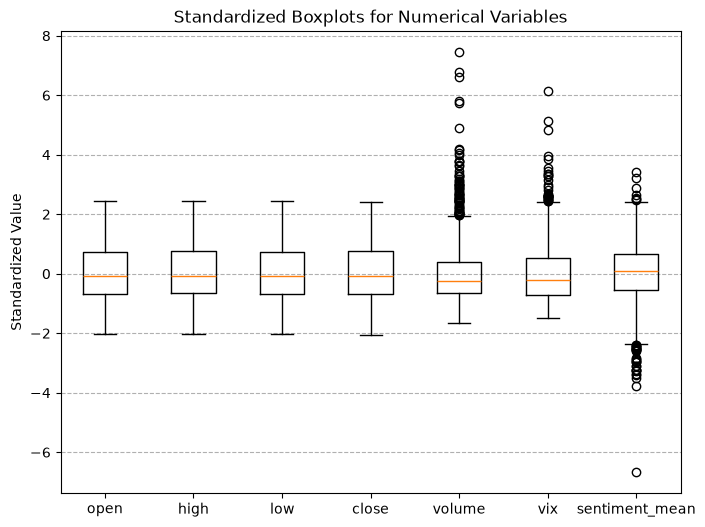

In [33]:
# Check for outliers
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cols = ["open", "high", "low", "close", "volume", "vix", "sentiment_mean"]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[cols])

plt.figure(figsize=(8,6))
plt.boxplot(df_scaled, tick_labels=cols)
plt.title("Standardized Boxplots for Numerical Variables")
plt.ylabel("Standardized Value")
plt.grid(axis="y", linestyle="--")
plt.show()

#### Null values treatment

In [35]:
# Null values treatment
# cpi and unemployment have null values because Oct 2025 value is not extracted. Hence it will make sense to use ffill
df["cpi"] = df["cpi"].ffill()
df["unemployment"] = df["unemployment"].ffill()


In [36]:
# Verify that all null values are treated by counting nulls in each column
null_counts = df.isnull().sum()
print(null_counts)

# Check Oct 2025 cpi and unemployment value is filled with the previous record of Sep 2025
df.loc["2025-09-30":"2025-10-31"][["cpi","unemployment"]]

ticker            0
open              0
high              0
low               0
close             0
adjusted_close    0
volume            0
vix               0
cpi               0
gdp               0
unemployment      0
sentiment_mean    0
sentiment_std     0
news_count        0
dtype: int64


,cpi,unemployment
Date,,
2025-09-30,324.245,4.4
2025-10-01,324.245,4.4
2025-10-02,324.245,4.4
2025-10-03,324.245,4.4
2025-10-06,324.245,4.4
2025-10-07,324.245,4.4
2025-10-08,324.245,4.4
2025-10-09,324.245,4.4
2025-10-10,324.245,4.4


#### Final inspection of the dataset to ensure accuracy and cleaned data

In [38]:
# Check the updated statistical information after removal of null rows
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1505 entries, 2020-08-03 to 2026-07-30
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          1505 non-null   str    
 1   open            1505 non-null   float64
 2   high            1505 non-null   float64
 3   low             1505 non-null   float64
 4   close           1505 non-null   float64
 5   adjusted_close  1505 non-null   float64
 6   volume          1505 non-null   int64  
 7   vix             1505 non-null   float64
 8   cpi             1505 non-null   float64
 9   gdp             1505 non-null   float64
 10  unemployment    1505 non-null   float64
 11  sentiment_mean  1505 non-null   float64
 12  sentiment_std   1505 non-null   float64
 13  news_count      1505 non-null   int64  
dtypes: float64(11), int64(2), str(1)
memory usage: 214.5 KB


In [39]:
# Check cpi and unemployment values are correctly imputted
df1 = df[["cpi","unemployment"]]
df1.index = pd.to_datetime(df1.index)
impute_check = df1[(df1.index.year == 2025) & (df1.index.month == 10)]
print(impute_check.head(5),"\n",impute_check.tail(5))


                cpi  unemployment
Date                             
2025-10-01  324.245           4.4
2025-10-02  324.245           4.4
2025-10-03  324.245           4.4
2025-10-06  324.245           4.4
2025-10-07  324.245           4.4 
                 cpi  unemployment
Date                             
2025-10-27  324.245           4.4
2025-10-28  324.245           4.4
2025-10-29  324.245           4.4
2025-10-30  324.245           4.4
2025-10-31  324.245           4.4


In [40]:
# Inspect the statistical properties of numerical datatype
np.round(df.describe(exclude=[object,str]).T,2)

,count,mean,std,min,25%,50%,75%,max
open,1505.0,170.23,43.30,82.80,140.80,167.50,201.90,2.760800e+02
high,1505.0,172.25,43.58,83.48,143.32,168.99,205.59,2.785600e+02
low,1505.0,168.04,42.95,81.43,138.93,165.43,199.61,2.723800e+02
close,1505.0,170.16,43.26,81.82,140.39,167.32,202.61,2.749900e+02
adjusted_close,1505.0,170.16,43.26,81.82,140.39,167.32,202.61,2.749900e+02
volume,1505.0,59221994.22,28641324.08,11420500.00,40434700.00,52029300.00,70290000.00,2.726620e+08
vix,1505.0,19.75,5.30,11.86,15.99,18.58,22.64,5.233000e+01
cpi,1505.0,300.90,21.91,259.32,282.54,304.61,318.96,3.339800e+02
gdp,1505.0,22714.33,1066.30,20558.88,21967.04,22840.99,23586.54,2.426961e+04
unemployment,1505.0,4.41,1.06,3.40,3.70,4.10,4.40,8.400000e+00


#### Data visualization of the independent, dependent and correlation among variables

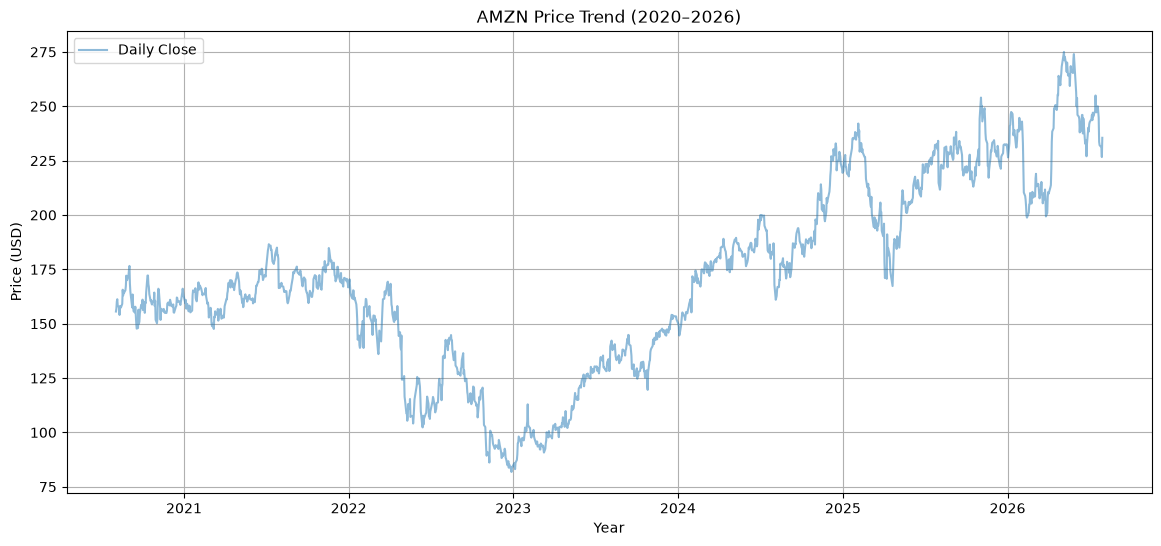

In [42]:
# Plot market price trend using closing price
df1 = df.copy()

plt.figure(figsize=(14,6))

plt.plot(df1.index, df1["close"], 
         label="Daily Close", alpha=0.5)

# plt.title("AMZN Price Trend with Moving Averages (2020–2026)")
plt.title("AMZN Price Trend (2020–2026)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

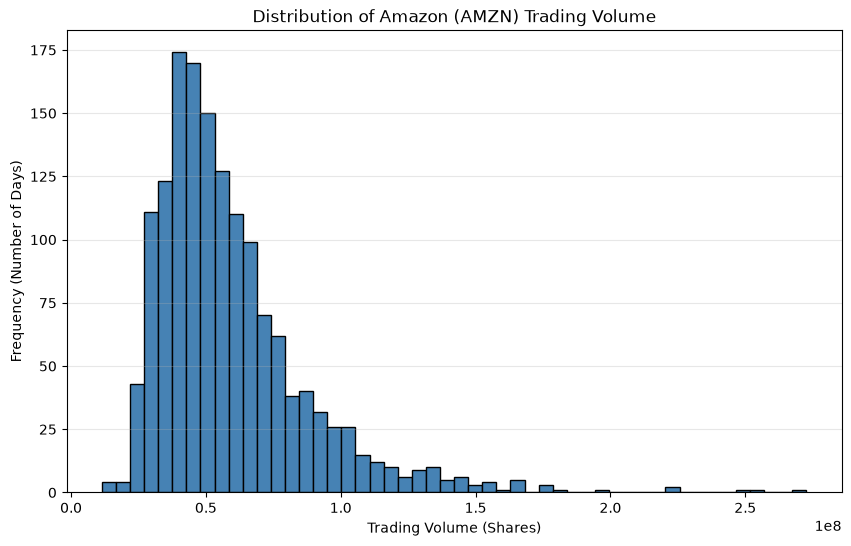

In [43]:
# Plot the trading volume

plt.figure(figsize=(10, 6))

plt.hist(df["volume"], 
         bins=50, 
         color="steelblue", 
         edgecolor="black")

plt.title("Distribution of Amazon (AMZN) Trading Volume")
plt.xlabel("Trading Volume (Shares)")
plt.ylabel("Frequency (Number of Days)")

plt.grid(axis="y", alpha=0.3)

plt.show()

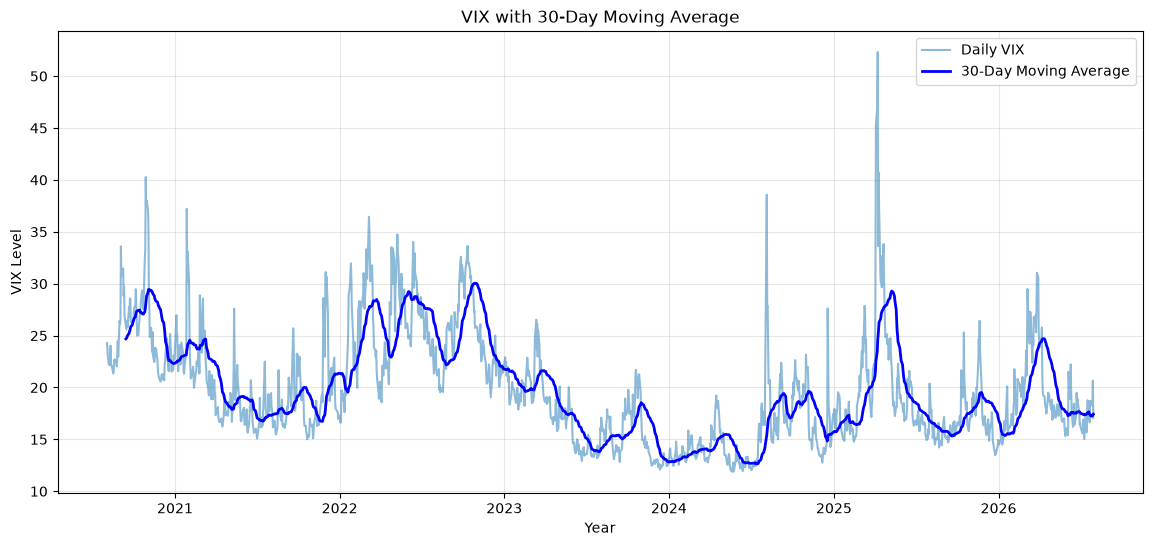

In [44]:
# Plot VIX with 30-day moving average
df1 = df.copy()
df1["VIX_MA30"] = df1["vix"].rolling(window=30).mean()

plt.figure(figsize=(14,6))

plt.plot(df1.index, df1["vix"],
         alpha=0.5,
         label="Daily VIX")

plt.plot(df1.index, df1["VIX_MA30"],
         color="blue",
         linewidth=2,
         label="30-Day Moving Average")

plt.title("VIX with 30-Day Moving Average")
plt.xlabel("Year")
plt.ylabel("VIX Level")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

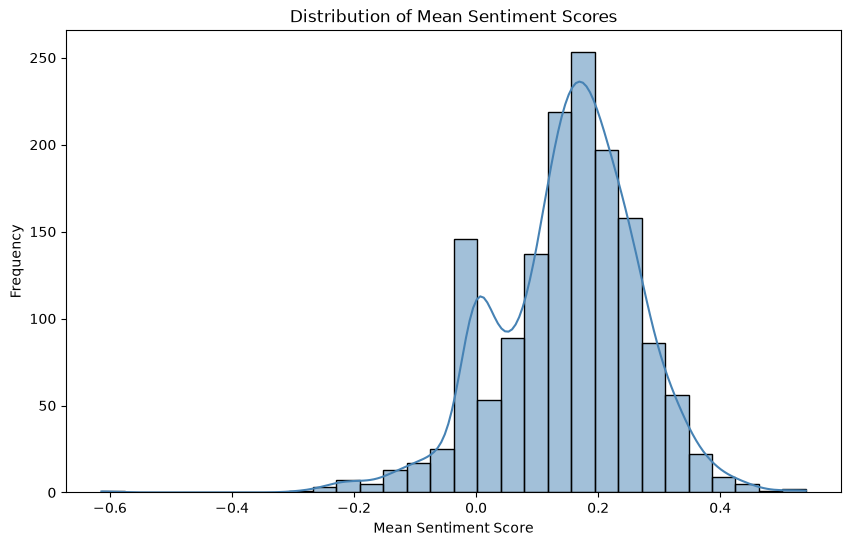

In [45]:
# Plot of sentiment mean
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(df["sentiment_mean"],
             bins=30,
             kde=True,
             color="steelblue")

plt.title("Distribution of Mean Sentiment Scores")
plt.xlabel("Mean Sentiment Score")
plt.ylabel("Frequency")

plt.show()

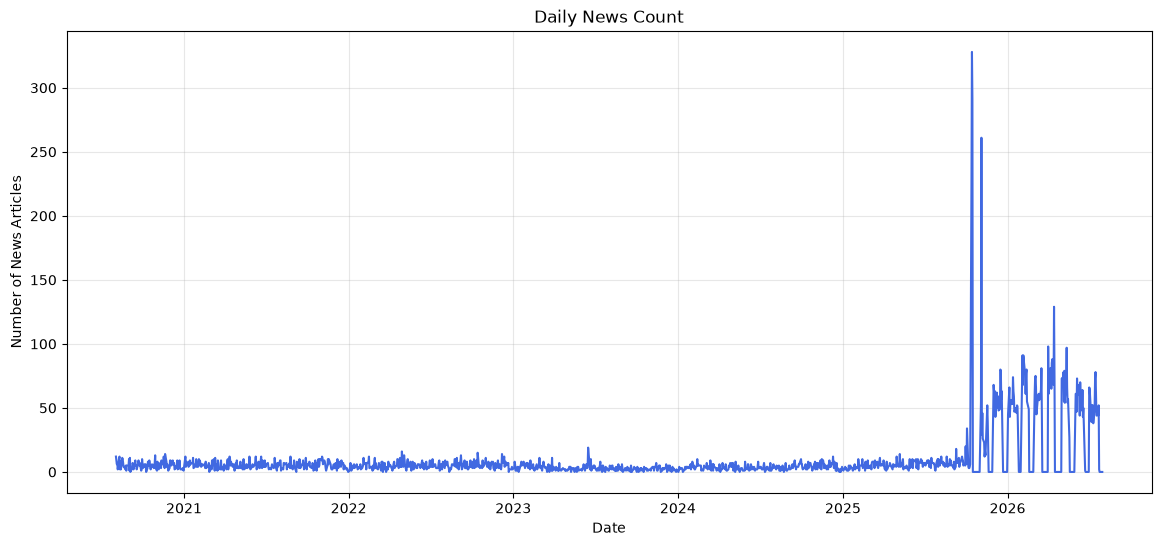

In [46]:
# Plot daily news count

plt.figure(figsize=(14,6))

plt.plot(df.index,
         df["news_count"],
         color="royalblue",
         linewidth=1.5)

plt.title("Daily News Count")
plt.xlabel("Date")
plt.ylabel("Number of News Articles")

plt.grid(alpha=0.3)
plt.show()


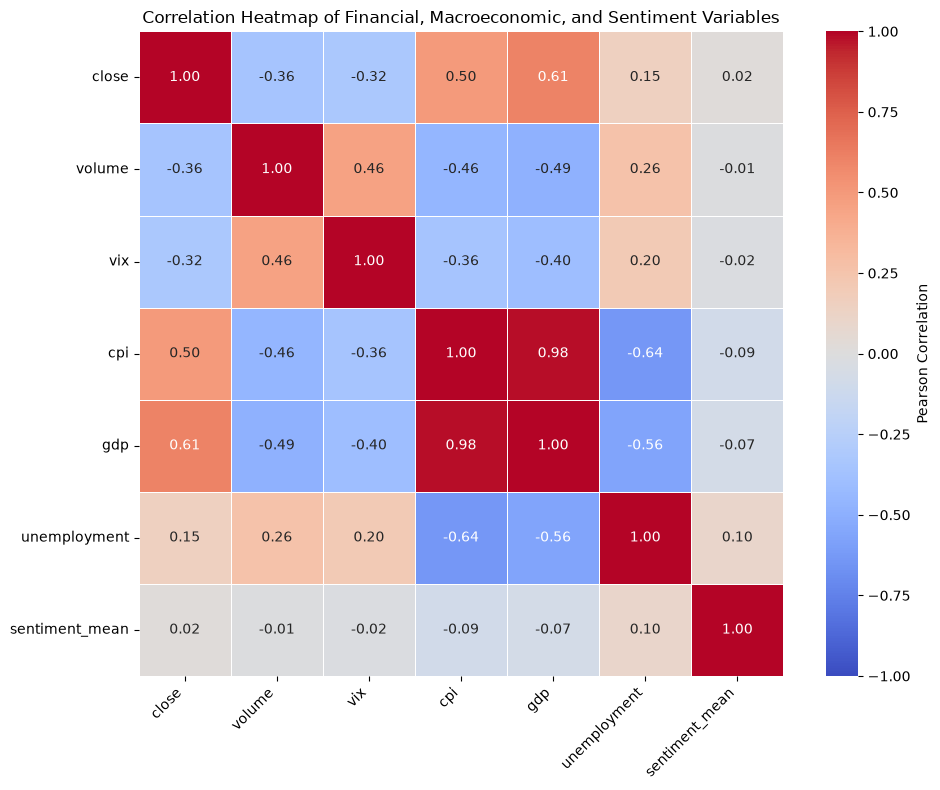

In [47]:
# Plot correlation matrix among all numerical variables to observe the strength of the linear relationship among them
import matplotlib.pyplot as plt
import seaborn as sns

# Select variables for correlation analysis
corr_vars = [
    "close",
    "volume",
    "vix",
    "cpi",
    "gdp",
    "unemployment",
    "sentiment_mean",
]

# Compute correlation matrix
corr_matrix = df[corr_vars].corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation coefficients
    cmap="coolwarm",     # Blue = negative, Red = positive
    fmt=".2f",           # Two decimal places
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Correlation Heatmap of Financial, Macroeconomic, and Sentiment Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [48]:
# Calculate the VIF scores
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select features to test for multicollinearity
features = ['cpi', 'gdp', 'unemployment']
df_numeric = df.select_dtypes(include=["number"])[features]

# Create the VIF dataframe
vif_data = pd.DataFrame()
vif_data["Feature"] = features

# Calculate VIF safely
vif_data["VIF"] = [
    variance_inflation_factor(df_numeric.values, i)
    for i in range(df_numeric.shape[1])
]

# Sort by VIF descending and print the selected feature with VIF value
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data)

        Feature          VIF
0           gdp  3762.410954
1           cpi  3211.153988
2  unemployment    37.060273


In [49]:
# To capitalize the open, high, low, close
df = df.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close'
})

# Save the cleaned market data
output_file = "data/cleaned_market_data.csv"
df.to_csv(output_file)

# Print the summary of the saved consalidated file
print(f"Saved {len(df):,} rows to {output_file}")


Saved 1,505 rows to data/cleaned_market_data.csv
